## Import Libraries and Set Directories

In [1]:
#! git clone https://github.com/MichPrencipe/swin2sr.git

In [1]:
import sys
sys.path.append('/home/michele.prencipe/tesi/transformer/swin2sr')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from data_loader.read_mrc import read_mrc
from tests.training import *
from skimage import io
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.ion()   # interactive mode

/localscratch/miniforge3/envs/transformer/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from configs.config import get_config
from predtiler.dataset import get_tiling_dataset, get_tile_manager
from data_loader.dataloader import SplitDataset

config = {
    "data_type": "biosr",    
    "data": {'noisy_data': True, 'poisson_factor': 0, 'gaussian_factor': 3400},
    "data_shape": (5,1004,10004),
    "learning_rate": 0.001,    
    "batch_size":2,
    "upscale": 1,
    "in_chans": 1,
    "patch_size": 1,
    "img_size": (256, 256),
    "window_size": 8,
    "img_range": 1.0,
    "depths":  [6, 6, 6, 6], 
    "embed_dim": 60,
    "num_heads": [6, 6, 6, 6],
    "mlp_ratio": 2,
    "upsampler": "pixelshuffledirect"
    }

data_type = config['data_type']
noisy_data = config['data']['noisy_data']
data_shape = (5,1004,1004)

gaussian_noises = [3400, 5100, 6800, 13600]
poisson_noises = [0]

patch_size = 256
tile_size = 128

manager = get_tile_manager(data_shape=data_shape, tile_shape=(1,tile_size,tile_size), 
                               patch_shape=(1,patch_size,patch_size))

    
dset_class = get_tiling_dataset(SplitDataset, manager)
dataset = dset_class(           data_type = data_type,
                                patch_size = patch_size,
                                transform = None,
                                noisy_data = False,
                                poisson_factor = 0, 
                                gaus_factor = 0,
                                mode = 'Test'
                                )

inp, targ = test_loader.dataset[0]
input_image = dataset.data[0,..., 0]
visual_data = [input_image]

for gaussian_noise in gaussian_noises:
    noisy_image = np.random.normal(0,gaussian_noise, (input_image.shape))
    noisy_image = input_image + noisy_image
    visual_data.append(noisy_image)
    
poisson =  np.random.poisson(input_image / 1000) * 1000
input_image = input_image + poisson
for gaussian_noise in gaussian_noises:
    noisy_image = np.random.normal(0,gaussian_noise, (input_image.shape))
    noisy_image = input_image + noisy_image
    visual_data.append(noisy_image)

print(len(visual_data))
print("Data Type:", data_type)
print("Noisy Data:", noisy_data)
print("Data Shape:", tuple(data_shape))

Norm Param:  0.0 0.0 65535.0 65535.0 94844.0 0.0
c1_data shape: (1004, 1004, 5)
c2_data shape: (1004, 1004, 5)


ValueError: lam < 0 or lam contains NaNs

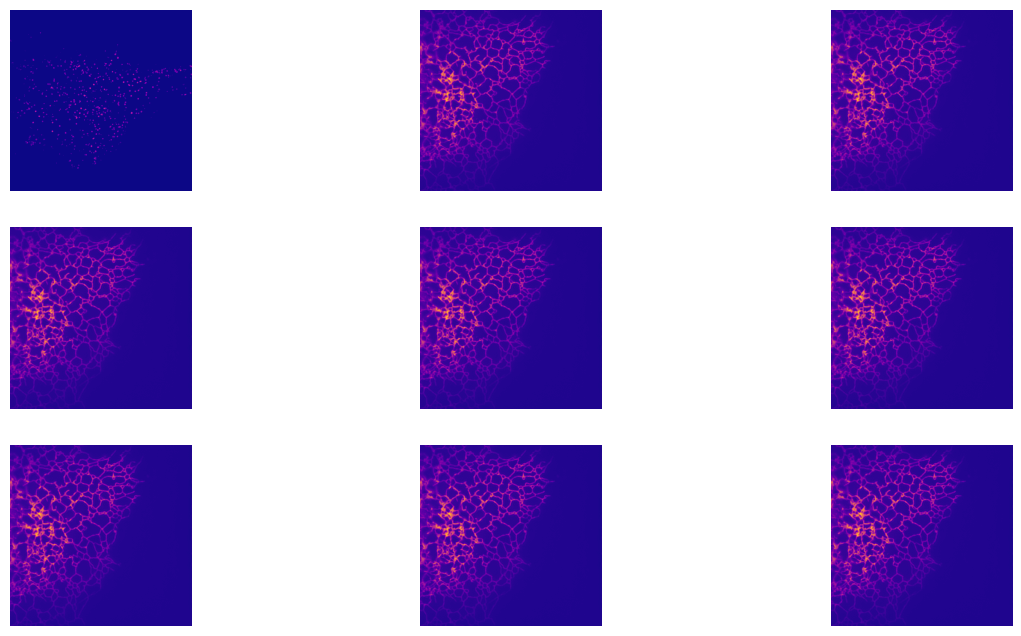

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Supponiamo di avere una lista di 8 immagini come array numpy
images = visual_data # Sostituisci con i tuoi array di immagini reali

# Crea una figura e una griglia di subplot 2x4
fig, axes = plt.subplots(3, 3, figsize=(15, 8))

# Itera su ogni subplot per visualizzare un'immagine
for idx, ax in enumerate(axes.flat):
    if idx < len(images):
        # Visualizza l'immagine come una mappa di intensità
        ax.imshow(images[idx], cmap='plasma')
    ax.axis('off')  # Rimuove assi per una migliore visualizzazione


plt.show()

